#  Netflix Data Analysis Project
### Exploratory Data Analysis using Python & Seaborn

## 1. Introduction

This project analyzes Netflix content data to understand trends, distribution, and patterns in movies and TV shows using data visualization techniques.

## 2. Data Loading

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## 3. Data Understanding

In [22]:
df.shape
df.columns
df.duplicated()


0       False
1       False
2       False
3       False
4       False
        ...  
8802    False
8803    False
8804    False
8805    False
8806    False
Length: 8807, dtype: bool

In [23]:
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

## 4. Data Cleaning
I performed data cleaning by handling missing values and removing duplicates to improve the quality of the dataset before analysis.

In [24]:
df.drop_duplicates(inplace=True)

df.fillna({
    'director': 'Unknown_director',
    'cast': 'Unknown_cast',
    'country': 'Unknown',
    'rating': 'Unknown',
    'date_added':'Unknown'
}, inplace=True)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown_cast,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown_director,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Unknown_director,Unknown_cast,Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Unknown_director,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,Unknown_director,Unknown_cast,Unknown,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


## 5. Exploratory Data Analysis

## Movies vs TV Shows Distribution

C:\Users\prate\AppData\Local\Temp\ipykernel_2620\1294870155.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='type', data=df, palette='Set2')


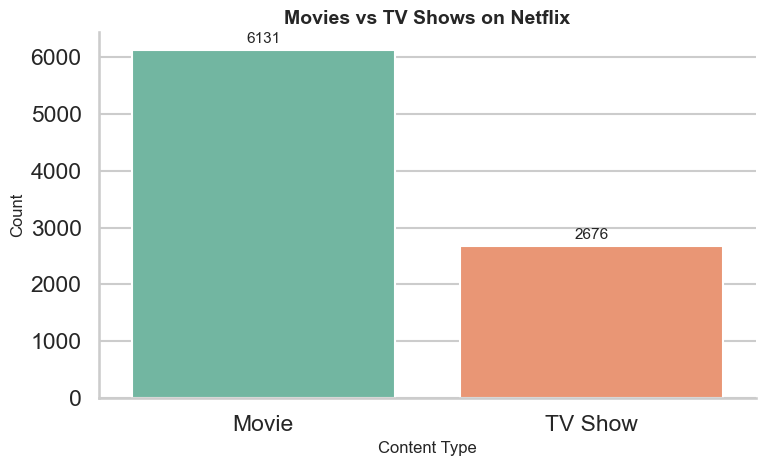

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.set_style("whitegrid")

ax = sns.countplot(x='type', data=df, palette='Set2')

plt.xlabel("Content Type", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.title("Movies vs TV Shows on Netflix", fontsize=14, fontweight='bold')

for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=11)

sns.despine()
plt.tight_layout()
plt.show()

### Insight:
I observed that movies dominate the Netflix catalog compared to TV shows. This indicates that Netflix focuses more on film-based content, as movies are generally easier to consume and attract a broader audience.

## Top Content Producing Countries

C:\Users\prate\AppData\Local\Temp\ipykernel_2620\2146626321.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_country.values, y=top_country.index,palette='mako')


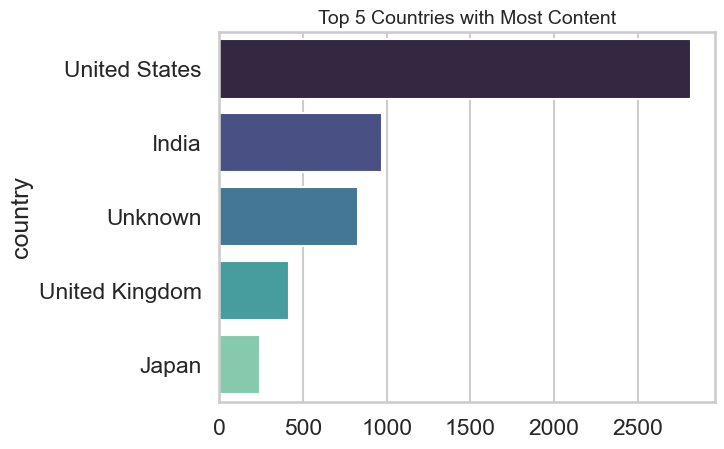

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

top_country = df['country'].value_counts().head(5)

sns.barplot(x=top_country.values, y=top_country.index,palette='mako')
plt.title("Top 5 Countries with Most Content",fontsize=14)


plt.show()

### Insight:
I found that the United States produces the highest amount of content on Netflix, followed by other countries. This shows that Netflix has a strong presence in the US while also expanding globally.

## Content Added Over the Years

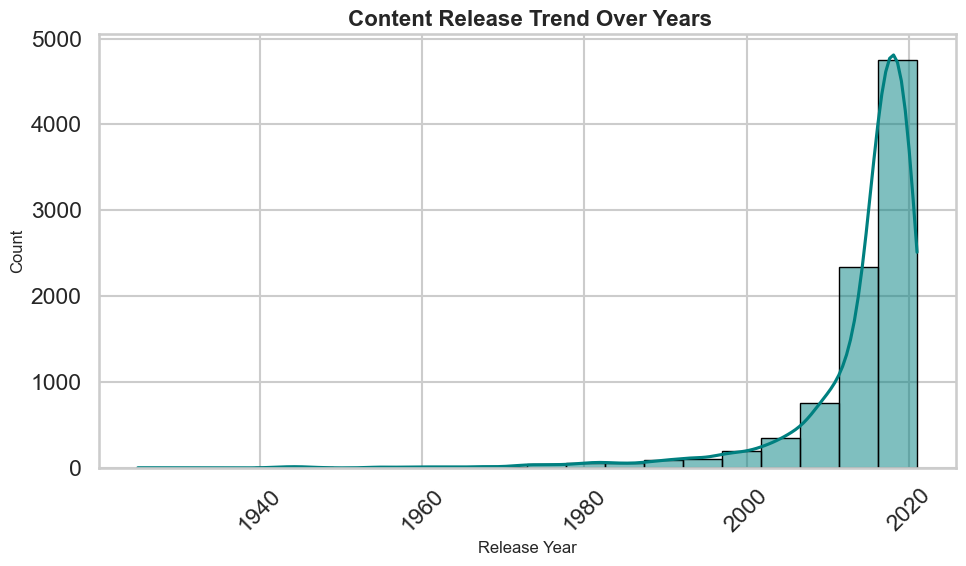

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.set_context("talk")

sns.histplot(df['release_year'], bins=20,kde=True,
             color="teal",edgecolor='black',linewidth=1)
plt.title(" Content Release Trend Over Years", fontsize=16, fontweight='bold')
plt.xlabel("Release Year", fontsize=12)
plt.ylabel("Count", fontsize=12)

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### Insight:
I noticed that the amount of content added on Netflix has increased significantly after 2015. This reflects the platform’s rapid growth and expansion in recent years.

## Content Rating Distribution

C:\Users\prate\AppData\Local\Temp\ipykernel_2620\4024348342.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


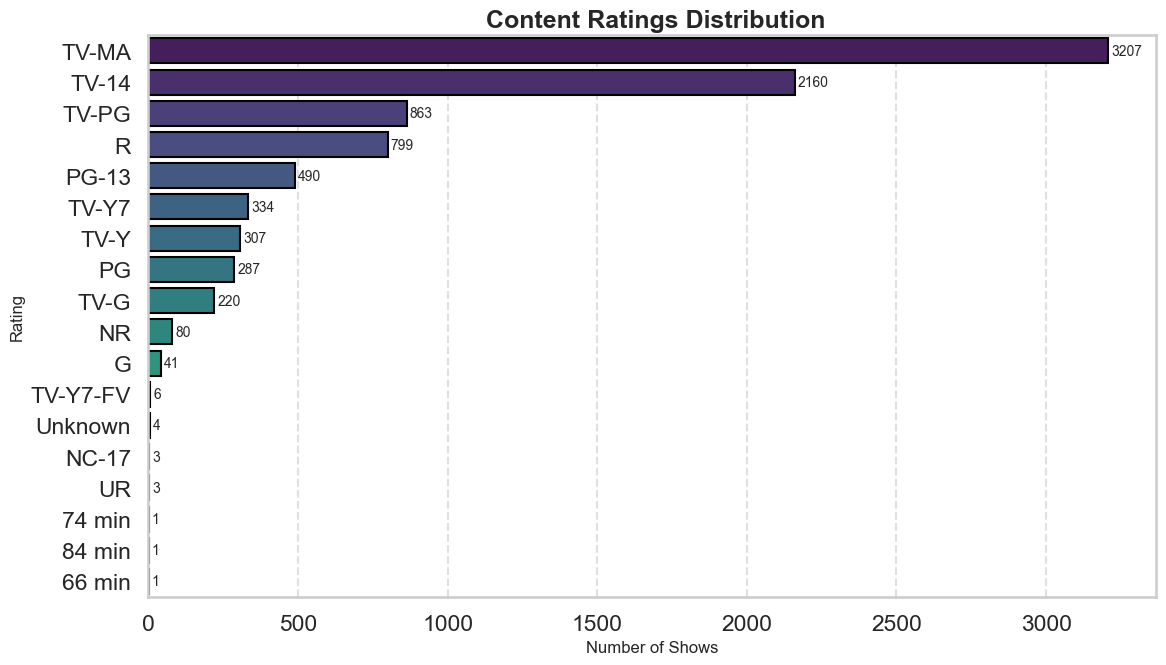

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(12,7))

sns.countplot(
    y='rating', 
    data=df, 
    order=df['rating'].value_counts().index,
    palette='viridis',
    edgecolor='black'
)

plt.title(" Content Ratings Distribution", fontsize=18, fontweight='bold')
plt.xlabel("Number of Shows", fontsize=12)
plt.ylabel("Rating", fontsize=12)

plt.grid(axis='x', linestyle='--', alpha=0.6)

for i, v in enumerate(df['rating'].value_counts()):
    plt.text(v + 10, i, str(v), va='center', fontsize=10)

plt.tight_layout()
plt.show()

### Insight:
I observed that most of the content on Netflix falls under TV-MA and TV-14 ratings. This indicates that the platform mainly targets mature and teenage audiences.

## Movie Duration Distribution

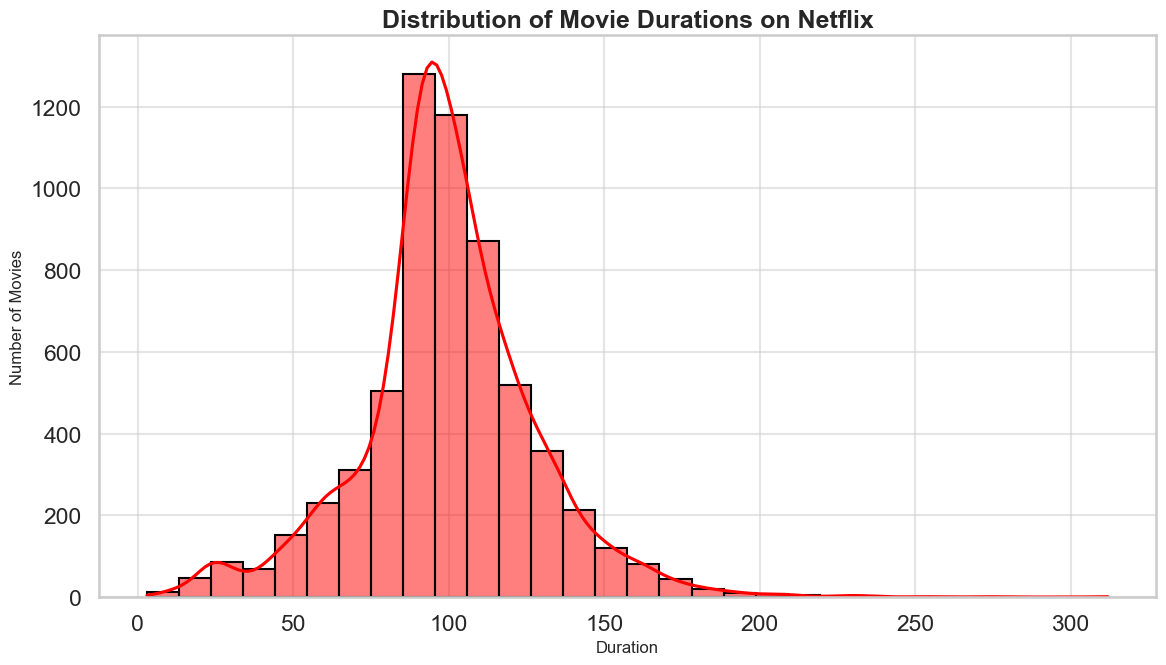

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df['duration'] = df['duration'].astype(str)
df['duration'] = df['duration'].str.replace(' min', '')
df['duration'] = pd.to_numeric(df['duration'], errors='coerce')

plt.figure(figsize=(12,7))
sns.histplot(
    df['duration'], 
    bins=30, 
    kde=True,
    color='red', 
    edgecolor='black'
)
plt.title("Distribution of Movie Durations on Netflix", fontsize=18, fontweight='bold')
plt.xlabel("Duration", fontsize=12)
plt.ylabel("Number of Movies", fontsize=12)

plt.grid("dark",alpha=0.5)
plt.tight_layout()
plt.show()

### Insight:
I observed that most movies on Netflix fall within the 80 to 120 minutes range. This indicates that Netflix prefers standard-length movies that align with typical viewer attention spans and industry norms.

## Genre Analysis

C:\Users\prate\AppData\Local\Temp\ipykernel_2620\260611640.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_genres.values, y=top_genres.index,palette='cividis',edgecolor="black",linewidth=1.4)


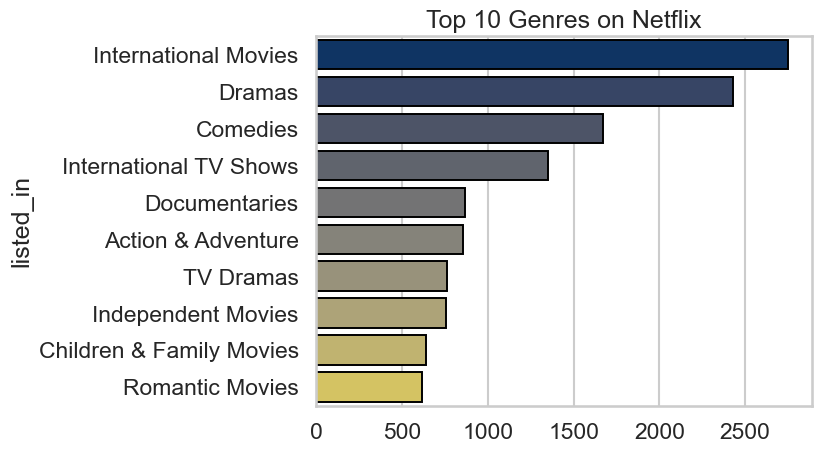

In [30]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


genres = df['listed_in'].str.split(', ')
all_genres = genres.explode()
top_genres = all_genres.value_counts().head(10)

sns.barplot(x=top_genres.values, y=top_genres.index,palette='cividis',edgecolor="black",linewidth=1.4)
plt.title("Top 10 Genres on Netflix")
plt.show()

### Insight:
I found that International Movies and Dramas dominate Netflix’s catalog. This indicates that Netflix focuses on global content and aims to reach a wide and diverse audience.

## Key Insights

- I observed that movies dominate Netflix content compared to TV shows, indicating a strong focus on film-based content.

- I found that the United States is the leading content producer on Netflix, highlighting its strong presence along with global expansion.

- I noticed a significant increase in content added after 2015, reflecting Netflix’s rapid growth and expansion strategy.

- I observed that most content falls under TV-MA and TV-14 ratings, suggesting a primary focus on mature and teenage audiences.

- I found that the majority of movies have durations between 80 and 120 minutes, indicating a preference for standard-length content.

- I observed that International Movies and Dramas dominate the platform, highlighting Netflix’s emphasis on global and diverse content.

## 6.Conclusion

In this project, I performed an exploratory data analysis on the Netflix dataset to understand content distribution and trends. I analyzed various aspects such as content type, genres, ratings, and release patterns.

Through this analysis, I observed that Netflix primarily focuses on movies and internationally diverse content. Popular genres like Drama and Comedy were found to dominate the platform, indicating a preference for high-engagement content.

Additionally, I noticed a significant increase in content addition in recent years, which reflects Netflix’s rapid growth and expansion in the global market.